# 💼 Adult Income Classification using Decision Tree
### Môn: Machine Learning
#### 🔍 Mục tiêu: Dự đoán mức thu nhập (<=50K hoặc >50K) dựa trên thông tin cá nhân và nghề nghiệp

## 1️⃣ Giới thiệu bài toán
**Bài toán:** Phân loại mức thu nhập của người trưởng thành (Adult Income Classification)
- **Input:** 14 đặc trưng bao gồm: tuổi (age), trình độ học vấn (education), giờ làm việc (hours.per.week), nghề nghiệp (occupation), tình trạng hôn nhân (marital.status)...
- **Output:** Giá trị `income`, thể hiện mức thu nhập: <=50K hoặc >50K
- **Ứng dụng:** Phân tích nhân khẩu học, hỗ trợ chính sách xã hội, dự đoán khả năng tín dụng
- 📘 **Mô hình sử dụng:** Decision Tree Classifier (cây quyết định) – dễ hiểu, dễ trực quan hóa, phù hợp cho bài toán phân loại.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

## 3️⃣ Tải và khám phá dữ liệu

In [2]:
data = pd.read_csv("adult.csv")
data = data.replace('?', np.nan)  
data = data.dropna()
data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


In [3]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 1 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   fnlwgt          30162 non-null  int64 
 3   education       30162 non-null  object
 4   education.num   30162 non-null  int64 
 5   marital.status  30162 non-null  object
 6   occupation      30162 non-null  object
 7   relationship    30162 non-null  object
 8   race            30162 non-null  object
 9   sex             30162 non-null  object
 10  capital.gain    30162 non-null  int64 
 11  capital.loss    30162 non-null  int64 
 12  hours.per.week  30162 non-null  int64 
 13  native.country  30162 non-null  object
 14  income          30162 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1.897938e+05,10.121312,1092.007858,88.372489,40.931238
std,13.134665,1.056530e+05,2.549995,7406.346497,404.298370,11.979984
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176272e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.784250e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376285e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### Kiểm tra phân phối mức thu nhập

C:\Users\duchu\AppData\Local\Temp\ipykernel_24648\3069258176.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=data, palette='viridis')


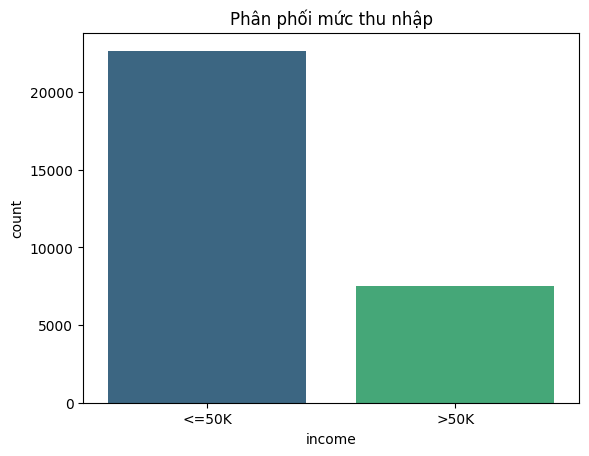

In [4]:
sns.countplot(x='income', data=data, palette='viridis')
plt.title('Phân phối mức thu nhập')
plt.show()

## 4️⃣ Tiền xử lý dữ liệu

### Mã hoán dữ liệu chuỗi

In [5]:
#choose a subset of data for faster processing
data = data.sample(n=5000, random_state=42)

# Encode categorical variables
le = LabelEncoder()
categorical_columns = data.select_dtypes(include=['object']).columns

for col in categorical_columns:
    if col != 'income':  # Don't encode target yet
        data[col] = le.fit_transform(data[col].astype(str))

### Tách tập dữ liệu

In [6]:
# Separate features and target
X = data.drop(columns=['income'])
y = le.fit_transform(data['income'])  # Encode target: <=50K -> 0, >50K -> 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 5️⃣ Huấn luyện mô hình Decision Tree

In [32]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

## 6️⃣ Đánh giá mô hình

In [33]:
print("Accuracy (Train):", accuracy_score(y_train, clf.predict(X_train)))
print("Accuracy (Test):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

Accuracy (Train): 0.84475
Accuracy (Test): 0.846

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.86      0.95      0.90       754
        >50K       0.77      0.53      0.63       246

    accuracy                           0.85      1000
   macro avg       0.82      0.74      0.77      1000
weighted avg       0.84      0.85      0.84      1000



### Ma trận nhầm lẫn (Confusion Matrix)

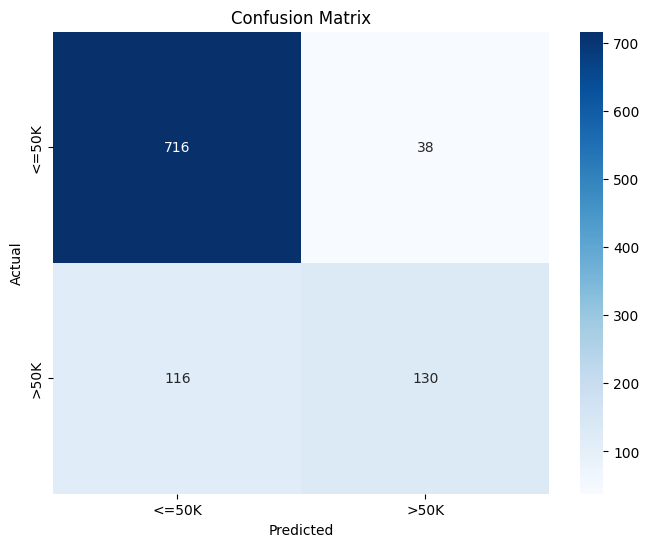

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 7️⃣ Phân tích độ quan trọng của các đặc trưng (Feature Importance)

C:\Users\duchu\AppData\Local\Temp\ipykernel_24400\2062186452.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature', palette='mako')


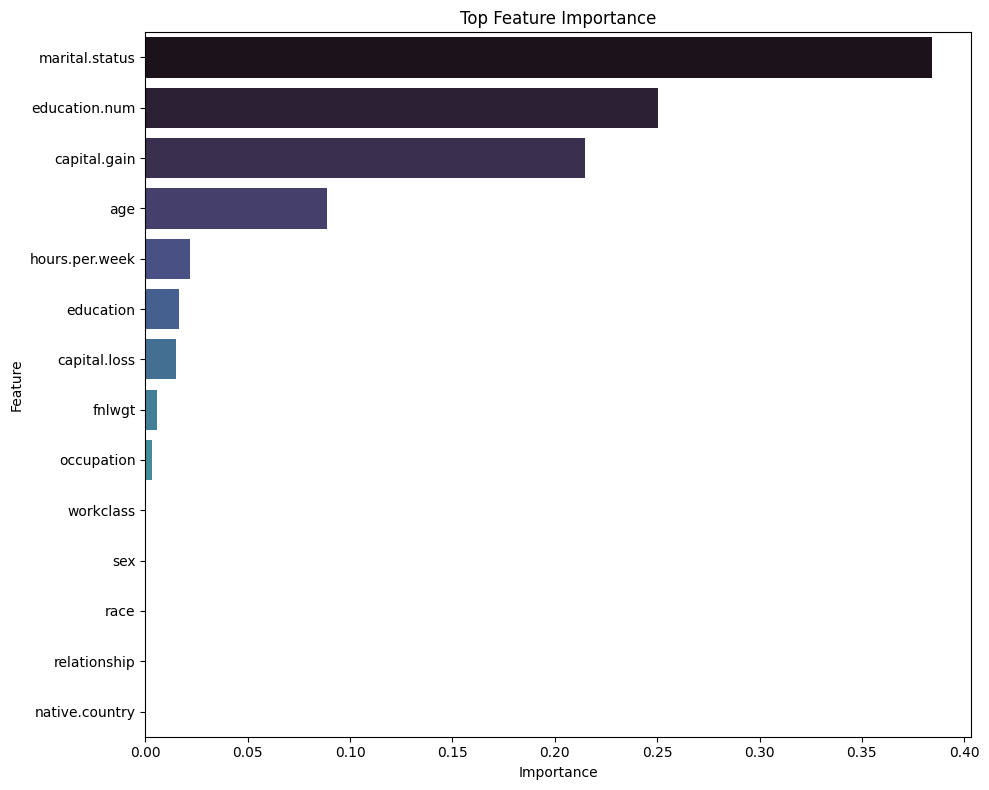

In [10]:
importance = clf.feature_importances_
feature_names = X.columns
feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importance})
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature', palette='mako')
plt.title('Top Feature Importance')
plt.tight_layout()
plt.show()

## 8️⃣ Minh họa cây quyết định

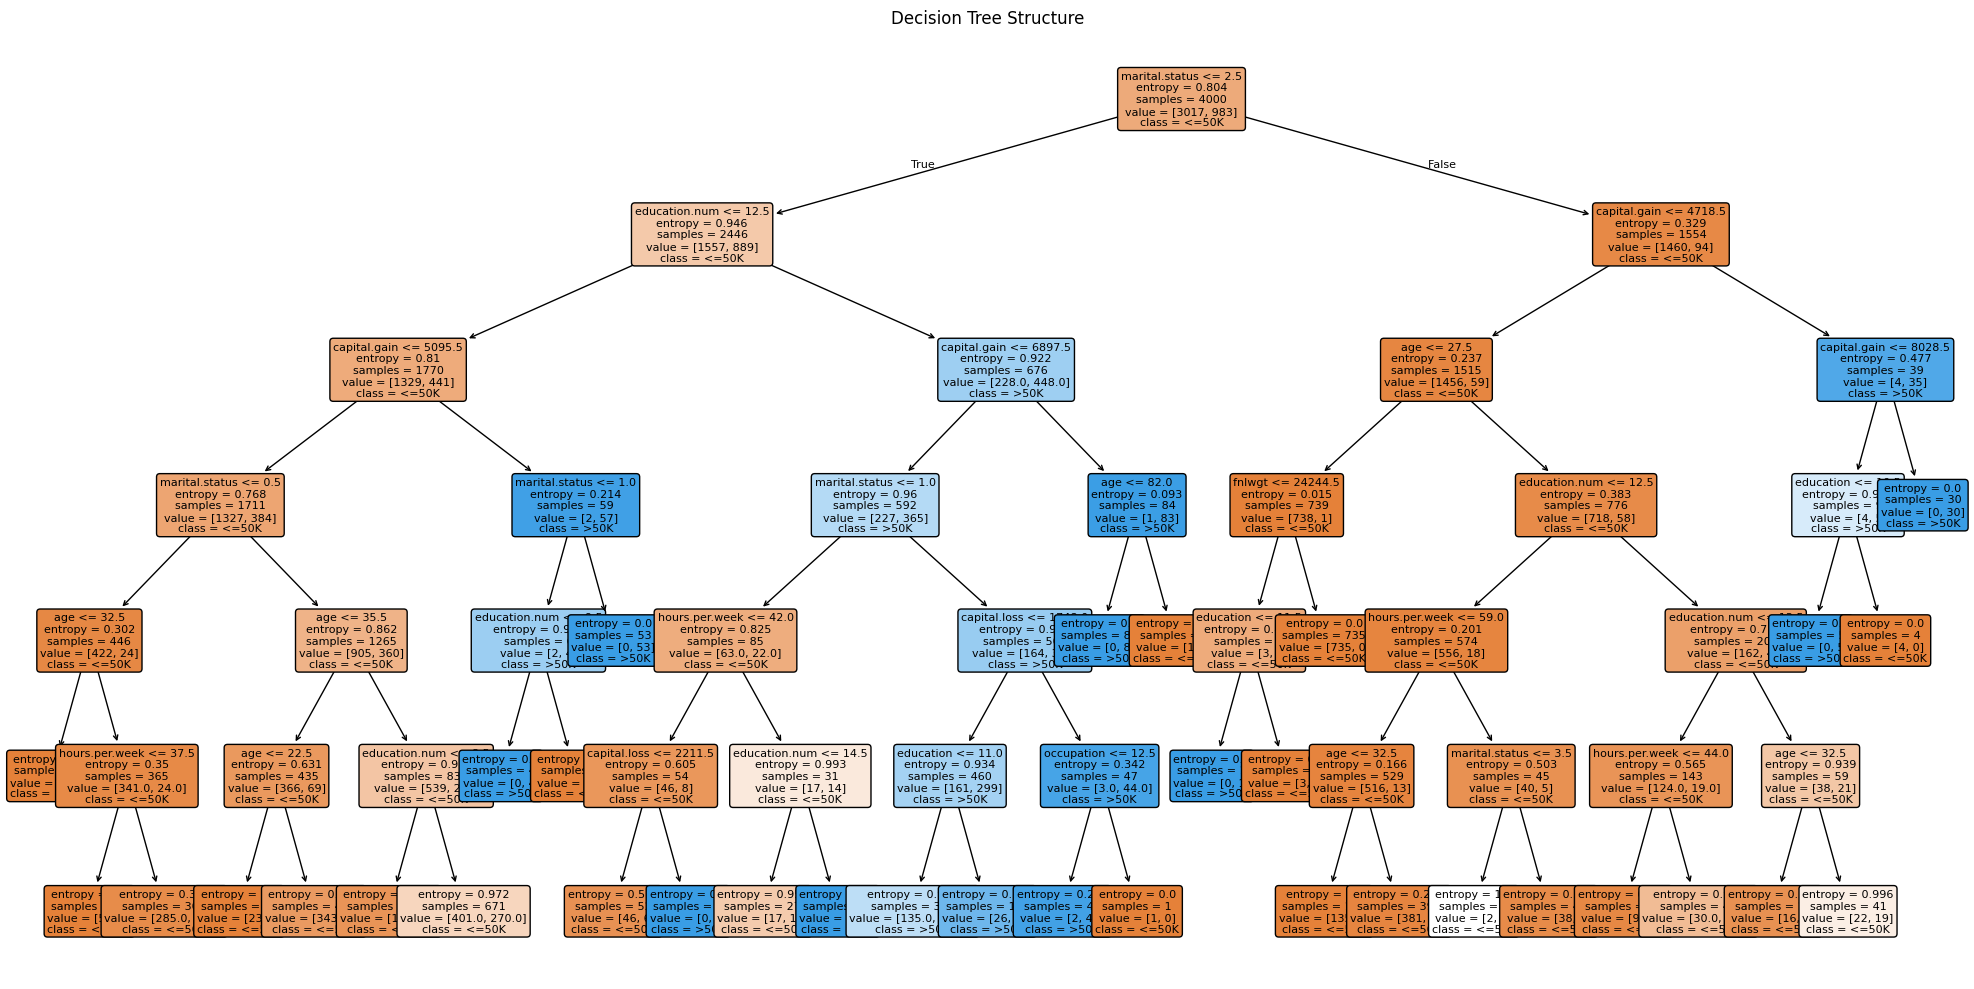

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=['<=50K', '>50K'],
          filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree Structure")
plt.tight_layout()
plt.show()